# Tick Imbalance Bars

## Buy- and Sell-Initiated Ticks

In this chapter we introduce **Tick Imbalance Bars (TIBs)**. Before discussing the core idea, we first define several auxiliary concepts on which TIBs are built.

Tick Imbalance Bars are constructed from **trading ticks**. Each trading tick represents an executed trade and is characterized by two quantities: **price** and **volume** (or trade size). Ticks arrive sequentially with irregular time intervals, so they are ordered chronologically, and each tick is associated with a specific point in time.

To construct TIBs, we use **only price information**. Neither volume nor time is used to classify trades. Each tick (trade) is classified as either **buy-initiated** or **sell-initiated** based on a comparison between its price and the price of the previous tick.

Specifically, if the price of the current tick is **higher** than the price of the previous tick, the trade is classified as **buy-initiated**. If the price of the current tick is **lower** than the previous price, the trade is classified as **sell-initiated**.

The intuition behind this classification is as follows. In a limit order book, **ask prices** (offers to sell) are always higher than **bid prices** (offers to buy). When a **market buy order** is executed, it consumes liquidity at **the best ask price**, which is higher than **the best bid price**. Conversely, a **market sell order** executes at the best bid price. This difference is known as the **bid–ask spread**.

An increase in the transaction price typically indicates one of two situations:

1. A transition from execution at the bid to execution at the ask, corresponding to a switch from a sell market order to a buy market order.
2. A buy market order that consumes all available liquidity at the best ask price and continues executing at a higher ask level.

In both cases, a higher transaction price signals the presence of a **buy market order**. Therefore, when the current trade price is higher than the previous trade price, we classify the trade as **buy-initiated**. Analogously, when the trade price decreases relative to the previous trade, it is classified as **sell-initiated**.

There are cases where the current trade price is **equal** to the price of the previous trade. In this situation, the current trade inherits the classification of the previous one. The rationale is that unchanged prices usually indicate repeated executions at the same bid or the same ask price, implying that the trade direction (buy or sell) has not changed.

However, it should be noted that, there exist certain edge cases that we ignore because they occur infrequently and have little impact on aggregate results. For example, consider a buy market order that fully consumes all ask limit orders at a given price level. Suppose that immediately afterward, the same price level is replenished with bid limit orders, and the next market order is a sell. In this scenario, a sell-initiated trade may follow a buy-initiated trade at the same price. Although this situation violates the simple price-based classification rule, such cases are rare and are typically neglected in practice.

Here is a simple Python function that classifies ticks using only prices and returns +1 (buy-initiated) and −1 (sell-initiated), following the logic we discussed above.

In [1]:
def classify_ticks(prices):
    """
    Classify trades based on price changes.

    Parameters
    ----------
    prices : list or iterable of floats
        Sequence of trade prices in chronological order.

    Returns
    -------
    list of int
        Tick classifications:
        +1 -> buy-initiated
        -1 -> sell-initiated
    """
    if len(prices) < 2:
        return []

    classifications = []

    # Initial direction (can be chosen arbitrarily; here we default to buy)
    prev_sign = 1

    for i in range(1, len(prices)):
        if prices[i] > prices[i - 1]:
            sign = 1
        elif prices[i] < prices[i - 1]:
            sign = -1
        else:
            # Same price: inherit previous classification
            sign = prev_sign

        classifications.append(sign)
        prev_sign = sign

    return classifications

A simple example of usage:

In [3]:
prices = [100.0, 100.1, 100.1, 99.9, 100.0]
print(classify_ticks(prices))

[1, 1, -1, 1]


## Tick Imbalance

Now that we have introduced a **binary classification of ticks** as buy- or sell-initiated, we can define the concept of **tick imbalance**. Tick imbalance is defined as the cumulative sum of the binary tick labels:
$$
I_n = \sum_{i=1}^n b_i ,
$$
where ( $b_i \in {+1, -1}$).

This quantity represents the **net aggressive buying versus selling** in the market. When buy-initiated ticks dominate, the tick imbalance increases as more ticks are added. Conversely, when sell-initiated ticks dominate, the tick imbalance decreases.

Tick imbalance admits a useful **graphical interpretation** as a **binary random walk**. Each tick corresponds to a single step: a buy-initiated trade moves the process up by one unit, while a sell-initiated trade moves it down by one unit. Viewed this way, the evolution of tick imbalance is equivalent to the trajectory of a random walk with step sizes of 1.

Below, we present an example in which we generate a sequence of binary labels taking values ( +1 ) and ( -1 ). The value ( +1 ) occurs with a predefined probability. We then compute the cumulative sum of this sequence and plot the resulting tick imbalance process.

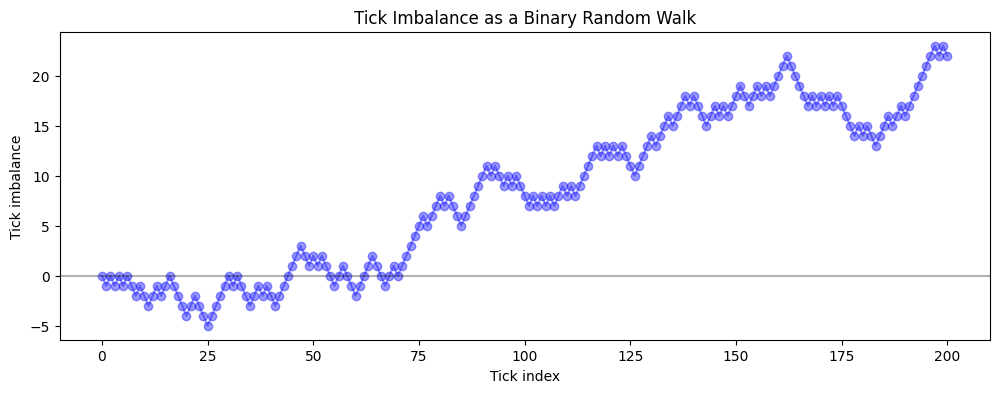

In [32]:
import random
import matplotlib.pyplot as plt

# Parameters
n_ticks = 200 # number of ticks' labels
p_buy = 0.55  # probability of +1 (buy-initiated)

# Generate binary labels (+1, -1)
labels = [1 if random.random() < p_buy else -1 for _ in range(n_ticks)]

# Compute cumulative sum (tick imbalance)
imbalance = [0]
current = 0
for b in labels:
    current += b
    imbalance.append(current)

# Plot tick imbalance
plt.figure(figsize = (12,4))
plt.plot(imbalance, marker = 'o', color = 'b', alpha = 0.4)
plt.xlabel("Tick index")
plt.ylabel("Tick imbalance")
plt.title("Tick Imbalance as a Binary Random Walk")
plt.axhline(y = 0, color = 'k', alpha = 0.3)
plt.show()

When working with tick imbalance, it is useful to be familiar with the concept of the **average tick imbalance after (N) steps**. One way to estimate this quantity empirically is to run the same process many times for (N) steps, record the tick imbalance at the end of each run, and then compute the average of these values.

In practice, however, this is unnecessary because the average tick imbalance can be derived analytically. If the probability of an upward move is ($p$), then the probability of a downward move is $(1 - p)$. The expected value of a single step is therefore $(+1) \cdot p + (-1) \cdot (1 - p) = 2p - 1$.

For example, if the probability of an upward move is (p = 0.6), then the expected change per step is: $2 \cdot 0.6 - 1 = 0.2$.

## Imbalance Threshold

Another important concept to introduce is the **imbalance threshold**. This concept is quite straightforward. At each step, we compute the tick imbalance and compare its absolute value to a predefined fixed number, which we call the **imbalance threshold**.

For example, if the imbalance threshold is set to 100, the threshold is considered reached whenever the tick imbalance equals +100 or −100, since the comparison is based on its absolute value. Once the threshold is reached, the current bar is closed and a new one is opened.

For a fixed process (that is, a binary random walk with a fixed probability of moving upward) and a fixed threshold, the number of steps required to reach the threshold (either above or below) is a random variable that can be described by a probability distribution. We begin by estimating this distribution numerically.

The following function gets a threshold and the probability of moving upward, and runs the process a predefined number of times. For each run, it records the number of steps (i.e., the duration) required to reach the threshold. The function returns a tuple consisting of a list of observed durations and the corresponding counts indicating how many times each duration occurred across all trials.

In [63]:
import random
from collections import defaultdict
import matplotlib.pyplot as plt

def simulate_hitting_time(threshold=10, p_up = 0.5, n_trials=100_000):

    counts = defaultdict(int)

    for _ in range(n_trials):
        imbalance = 0
        steps = 0

        while True:
            steps += 1
            step = 1 if random.random() < p_up else -1
            imbalance += step

            if abs(imbalance) == threshold:
                counts[steps] += 1
                break
                
    steps = sorted(counts)
    counts_ls = [counts[s] for s in steps]

    return steps, counts_ls

Here, we run the function with the same threshold but vary the probability of an upward move.

In [64]:
import numpy as np

n_trials=100_000
threshold=10

p_up_1 = 0.5
steps_1, counts_1 = simulate_hitting_time(threshold, p_up_1, n_trials)

p_up_2 = 0.6
steps_2, counts_2 = simulate_hitting_time(threshold, p_up_2, n_trials)

Let us first examine the minimum and maximum number of steps required to reach the threshold. The minimum number of steps is 10, because if the process happens to move in the same direction for 10 consecutive steps, it will reach the threshold. It is not possible to reach the threshold in fewer steps.

Another effect we observe is that when the process is unbalanced (that is, when the probability of moving in one direction is greater than in the other) the process tends to move more consistently in that direction. As a result, it takes less time on average for the process to reach the threshold.

This effect should be reflected in the maximum observed duration. For an unbalanced process, the maximum duration is expected to be smaller.

In [65]:
print('Minimal and maximal number of steps:\n')
print('Process 1:', min(steps_1), max(steps_1))
print('Process 2:', min(steps_2), max(steps_2))

Minimal and maximal number of steps:

Process 1: 10 1114
Process 2: 10 352


Let us now plot the counts of the different durations. As the plots will show, shorter durations occur more frequently in the unbalanced process, as explained above. In particular, the maximum, the most frequent, and the average durations are all smaller for the unbalanced process. We use a logarithmic scale for the duration (x-axis) to obtain a clearer and more readable representation.

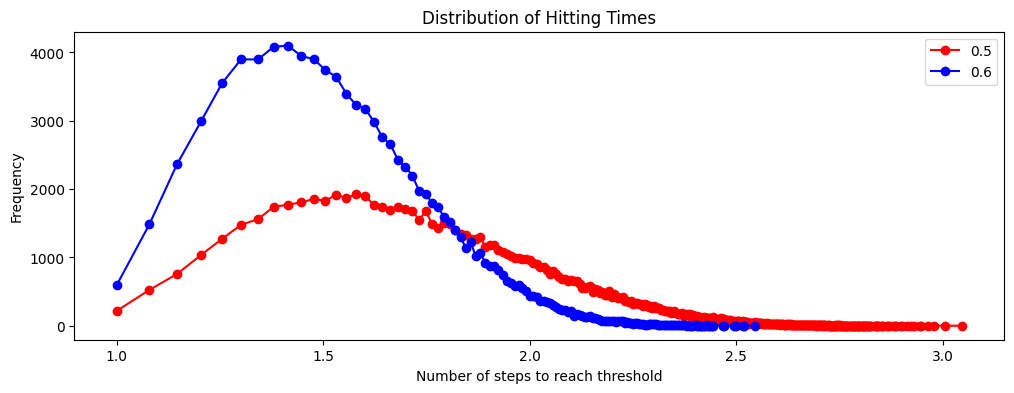

In [66]:
plt.figure(figsize = (12,4))
plt.plot(np.log10(steps_1), counts_1, label = p_up_1, color = 'r', marker = 'o')
plt.plot(np.log10(steps_2), counts_2, label = p_up_2, color = 'b', marker = 'o')
plt.xlabel("Number of steps to reach threshold")
plt.ylabel("Frequency")
plt.title("Distribution of Hitting Times")
plt.legend()
plt.show()

## Average Bar Size

In the previous section, we saw that for a given threshold and probability of an upward move, the number of steps required to reach the threshold is a stochastic (probabilistic) quantity: it varies from run to run. Different durations therefore occur with different probabilities, with some being more likely than others. These probability distributions can be computed numerically, as was done in the previous section.

One important property of this distribution is its average value, which indicates the average number of steps required to reach the threshold. Note that this property is complementary to (but not identical with) another quantity discussed in an earlier section: the average displacement (or imbalance) of the process after a fixed number of steps.

In the case of the average duration (number of steps), we fix the *y*-value (the threshold) and ask what the corresponding *x*-value (number of steps) is made on average when that level is reached. In contrast, for the average displacement, we fix the *x*-value (number of steps) and ask what the corresponding *y*-value (displacement) is on average after that many steps.

As with the distribution of durations, the mean duration can be computed numerically. However, there is fortunately an analytic solution that allows this quantity to be calculated exactly, easily, and efficiently. We will not derive this formula here, as it is beyond the scope of this lecture. Instead, we simply present the formula and encourage you to verify it through numerical simulations:
$$
\overline{D} = \frac{T}{p - q} \cdot \frac{p^T - q^T}{p^T + q^T},
$$
where $p$ and $q$ denote the probabilities of upward and downward moves, respectively ($p + q = 1$), and $T$ is the threshold. The above formula can also be expressed using the hyperbolic tangent and logarithm:
$$
\overline{D} = \frac{T}{p - q} \cdot \tanh \left[ \frac{T}{2} \cdot \ln \left( \frac{p}{q} \right) \right].
$$

The function below implements both versions of the formula. It takes the upward-move probability ($p$) and the threshold value ($T$) as its first two parameters, and the version selector as the third parameter. The output of the function is independent of the chosen version, as we will demonstrate below. The function returns the average duration—that is, the expected number of time steps required to reach the threshold.

Note that both formulas suffer from a computational issue (division by zero) when $p = 0.5$ ($p = q$). In this case, the correct approach is to take the limit as $p \to 0.5$. Evaluating this limit shows that the average duration is $T^2$. The function explicitly handles this edge case.

In [468]:
import numpy as np

def avg_t(p, T, version = 2):
    if p == 0.5:
        return pow(T, 2)
    q = 1.0 - p
    m1 = T / (p - q)
    if version == 1:
        pt = pow(p, T)
        qt = pow(q, T)   
        m2 = (pt - qt) / (pt + qt)
    if version == 2:
        m2 = np.tanh((T/2.0) * np.log(p/q))    
    return m1 * m2

In the following cells, we demonstrate how the average number of time steps required to reach the threshold depends on the probability of an upward move. We choose the threshold to be 10.

In [119]:
T = 6
n_points = 100
ps1, ts1 = [], []
ps2, ts2 = [], []
for _ in range(100):
    p1 = random.uniform(0.0, 1.0)
    p2 = random.uniform(0.0, 1.0)
    t1 = avg_t(p1, T, version = 1)
    t2 = avg_t(p2, T, version = 1)
    ps1.append(p1)
    ps2.append(p2)
    ts1.append(t1)
    ts2.append(t2)

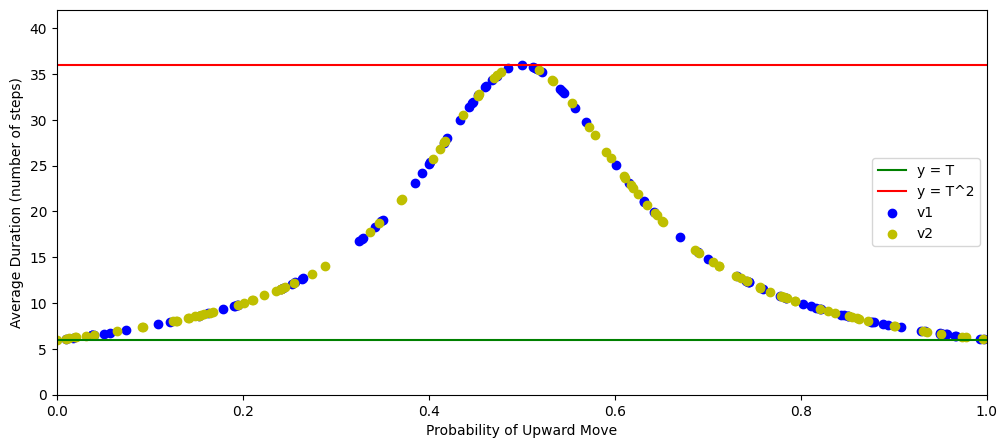

In [121]:
plt.figure(figsize = (12,5))
plt.ylim([0.0, T + T**2])
plt.xlim([0.0, 1.0])
plt.xlabel('Probability of Upward Move')
plt.ylabel('Average Duration (number of steps)')
plt.axhline(y = T, color = 'g', label = 'y = T')
plt.axhline(y = T**2, color = 'r', label = 'y = T^2')
plt.scatter(ps1, ts1, color = 'b', label = 'v1')
plt.scatter(ps2, ts2, color = 'y', label = 'v2')
plt.legend()
plt.show()

We can clearly identify two limiting cases. When the probability is very close to zero or one, the process moves almost deterministically in a single direction and therefore reaches the threshold after 10 steps. The other limiting case occurs when the probability is equal to 0.5. In this case, it takes $T^2$ steps on average to reach the threshold. In particular, for our example, it takes an average of 100 steps to reach a threshold of 10. This is a well-known result, which our formula must reproduce (and indeed it does).

## Threshold Update Rule



In [232]:
sim_len = 1000000000
p_up = 0.6

I, n = 0, 0
ns = []

n_exp = 100
b_exp = 2.0 * p_up - 1.0

n_exps, b_exps, Ts = [], [], []

T = n_exp * b_exp
for i in range(sim_len):
    
    b = 1 if random.random() < p_up else -1
    I += b
    n += 1

    b_exp = 0.99 * b_exp + 0.01*b 
    if abs(I) >= T:
        ns.append(n)
        n_exp = 0.99*n_exp + 0.01*n
        T = n_exp * abs(b_exp)

        n_exps.append(n_exp)
        b_exps.append(b_exp)
        Ts.append(T)
        
        I, n = 0, 0

        if len(ns) >= 10000:
            break

KeyboardInterrupt: 

## Bars Generator

When constructing a new bar, we rely on two inputs: (1) the expected (average) duration of previous bars, denoted by $D$, and (2) the expected drift speed $S$. As a first step, we multiply these two quantities to obtain a threshold value ($T$). The bar is closed as soon as this threshold is reached. In other words, the bar closes once the imbalance reaches the level that we would expect, on average, after $D$ steps. This interpretation requires some care: reaching this threshold does **not** imply that the bar will take (D) steps on average to close. 

Once a bar is opened, we observe a sequence of random movements (upward or downward). The probability of an upward move may be constant or may depend on the time step. After each movement, we update an exponential moving average that estimates the drift speed. When the threshold is reached and the bar is closed, we also update the expected duration of previous bars.

Different smoothing constants are used for the two exponential moving averages (drift speed and bar duration). With this setup in mind, we can now write a simulator that implements the procedure described above.

The function returns the updated expected duration, the updated expected speed, and the size of the bar (i.e., the duration of the current bar).

In [341]:
def build_bar(D, S, ind_to_prob, D_alpha, S_alpha):
    T = D * abs(S)
    ind, I = 0, 0
    while True:
        prob = ind_to_prob(ind)
        ind += 1
        b = 1 if random.random() < p_up else -1
        S = b * S_alpha + S * (1 - S_alpha)
        I += b
        if abs(I) >= T:
            break
    D = ind * D_alpha + D * (1 - D_alpha)
    return D, S, ind

Let us now consider a simple simulation. We start from an initial expected duration and set the expected drift speed equal to the true drift speed corresponding to a given probability of an upward move ($s = 2 \cdot p - 1$). We then construct a bar and examine the distribution of outcomes, namely the observed bar duration and the updated drift speed.

In [412]:
def get_i2p(p):
    def ip2(i):
        return p
    return ip2

In [414]:
i2p = get_i2p(0.3)
i2p(0)

0.3

In [436]:
random.random()

0.412038020549359

We set the threshold at the level one would be expected to reach after 100 steps on average. How many steps, on average, do you think it would take to reach this level? A naive intuition suggests 100 steps, but this is incorrect.

In [495]:
import math

p_ups = np.linspace(0.3, 0.7, num=101)

mean_durations = []
mean_durations2 = []
mean_durations3 = []
for p_up in p_ups:

    i2p = get_i2p(p_up)
    
    D = 100
    S = 2 * p_up - 1
    
    speeds, sizes = [], []
    
    for _ in range(10000):
        _, S_new, sz = build_bar(D, S, i2p, 0.01, 0.01)
        speeds.append(S_new)
        sizes.append(sz)

    mean_durations.append(np.mean(sizes))

    expected = avg_t(p_up, S*D)
    mean_durations2.append(expected)

    expected3 = avg_t(p_up, math.ceil(abs(S*D)))
    mean_durations3.append(expected3)

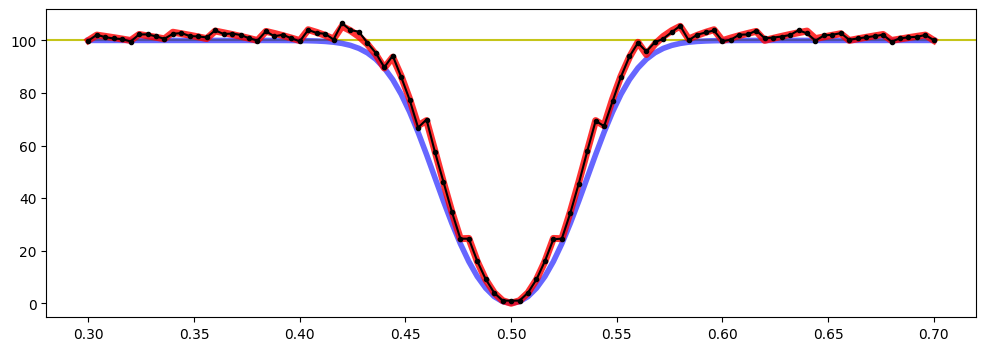

In [512]:
plt.figure(figsize = (12,4))
plt.axhline(y = 100, alpha = 0.9, color = 'y')
plt.plot(p_ups, mean_durations2, marker = '', color = 'b', alpha = 0.6, linewidth = 4)
plt.plot(p_ups, mean_durations3, marker = '', color = 'r', alpha = 0.8, linewidth = 5)
plt.plot(p_ups, mean_durations, marker = 'o', color = 'k', markersize = 3)
plt.show()

In [411]:
print(len(sizes), min(sizes), max(sizes), np.mean(sizes))

10000 11 729 88.7166


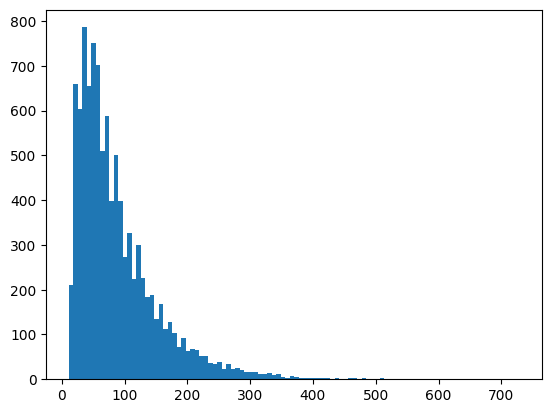

In [410]:

plt.hist(sizes, bins = 100)
plt.show()

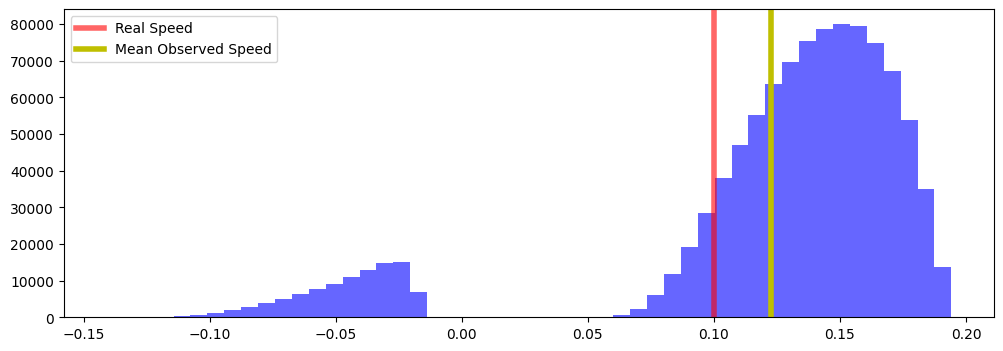

In [368]:
mean_speed = np.mean(speeds)

plt.figure(figsize = (12,4))
plt.hist(speeds, bins = 50, color = 'b', alpha = 0.6)
plt.axvline(x = S, color = 'r', alpha = 0.6, linewidth = 4, label = 'Real Speed')
plt.axvline(x = mean_speed, color = 'y', alpha = 1, linewidth = 4, label = f'Mean Observed Speed')
plt.legend()
plt.show()

In [302]:
np.arange(0.55, 1.0, 0.1)

array([0.55, 0.65, 0.75, 0.85, 0.95])

In [378]:
def get_i2p(p):
    def ip2(i):
        return p
    return ip2

In [395]:
p_ups = np.linspace(0.0, 1.0, num=101)
mean_speeds = []
for p_up in p_ups:
    
    ind_to_prob = get_i2p(p_up)
    
    D = 100
    S = 2 * p_up - 1
    
    speeds, sizes = [], []
    
    for _ in range(10000):
        _, S_new, sz = build_bar(D, S, ind_to_prob, 0.01, 0.01)
        speeds.append(S_new)
        sizes.append(sz)

    mean_speeds.append(np.mean(speeds))

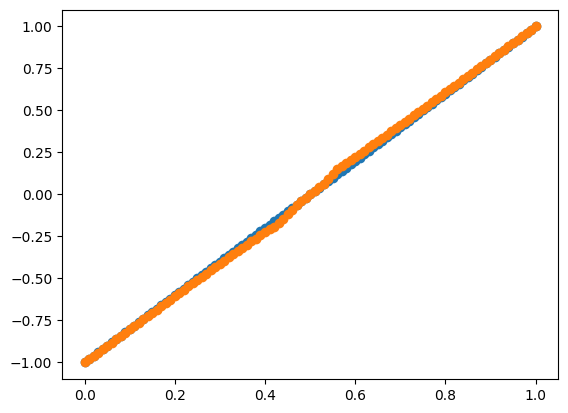

In [396]:
plt.plot(p_ups, 2*p_ups - 1, marker = 'o')
plt.plot(p_ups, mean_speeds, marker = 'o')

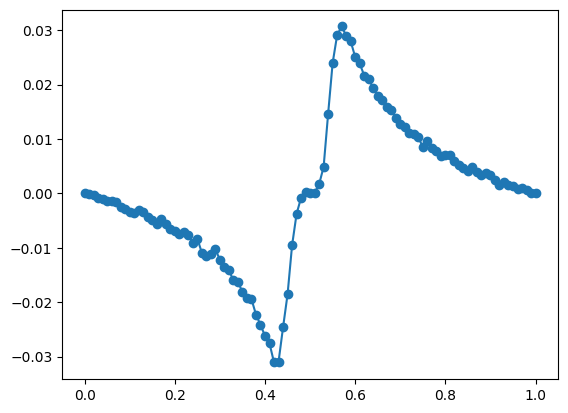

In [397]:

plt.plot(p_ups, mean_speeds - (2*p_ups - 1), marker = 'o')

In [398]:
2+2

4

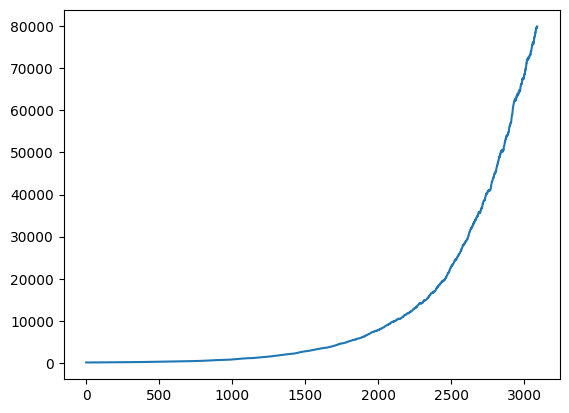

In [234]:
#plt.plot(Ts)
plt.plot(n_exps)
#plt.plot(b_exps)
#np.mean(b_exps)

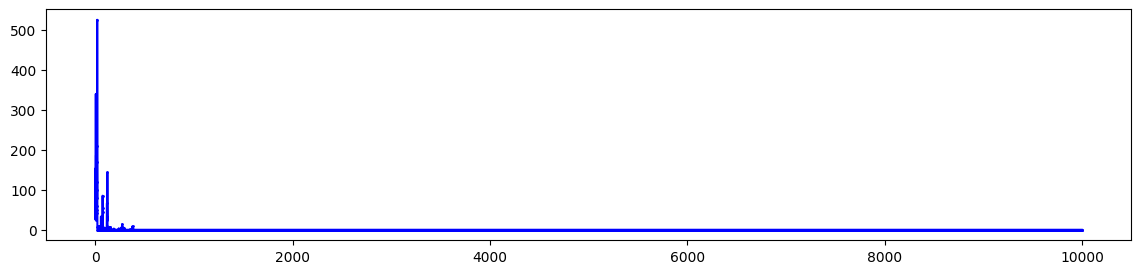

1.3804 1


In [231]:
plt.figure(figsize = (14,3))
#plt.xlim([0, len(ns)])
plt.plot(ns, marker = 'o', color = 'b', markersize = 1)
plt.show()

print(np.mean(ns), np.min(ns))

## 3. Estimate the imbalance threshold

Instead of using a fixed number, Tick Imbalance Bars use an **adaptive threshold**:

$$
\theta = E[N] \times |E[b]|
$$

Where:

* (E[N]) = expected number of ticks per bar (rolling average)
* (E[b]) = expected tick direction imbalance (rolling average)
* (\theta) = imbalance threshold

This makes the bar size **self-adjusting to market conditions**.

---

## 4. Bar formation rule

A bar closes when:

$$
\left| \sum_{i=1}^{N} b_i \right| \ge \theta
$$

At that moment:

* Open = first trade price
* High / Low = max / min trade price
* Close = last trade price
* Volume = total volume traded
* Tick count = number of trades

Then a **new bar starts immediately**.

---

## 5. Intuition (why it works)

Tick Imbalance Bars:

* Form **faster in trending markets**
* Slow down in **choppy or balanced markets**
* Highlight **aggressive participation**
* Reduce noise compared to time bars

They answer:

> “Has one side (buyers or sellers) *clearly taken control*?”

---

## 6. Simple pseudocode

```python
ticks = []
imbalance = 0

for tick in market_data:
    b = tick_direction(tick)
    ticks.append(tick)
    imbalance += b

    if abs(imbalance) >= threshold:
        create_bar(ticks)
        ticks = []
        imbalance = 0
```

---

## 7. Common variations

* Fixed imbalance threshold (simpler, less adaptive)
* Volume-weighted tick imbalance
* Combined with **Volume Imbalance Bars**
* Used as input for ML or regime detection

---

If you want, I can:

* Walk through a **numerical example**
* Help you **code this in Python / Pine / NinjaScript**
* Compare Tick Imbalance Bars vs **Volume** or **Dollar Bars**
* Explain **how to choose rolling window sizes**

Just tell me how deep you want to go.
